In [2]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import math
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("Libraries imported successfully!")

Using device: cuda
Libraries imported successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [128]:
import gc
gc.collect()

6919

Training samples: 21520
Test samples: 9000
Batch size: 128
Training batches: 169
Test batches: 71


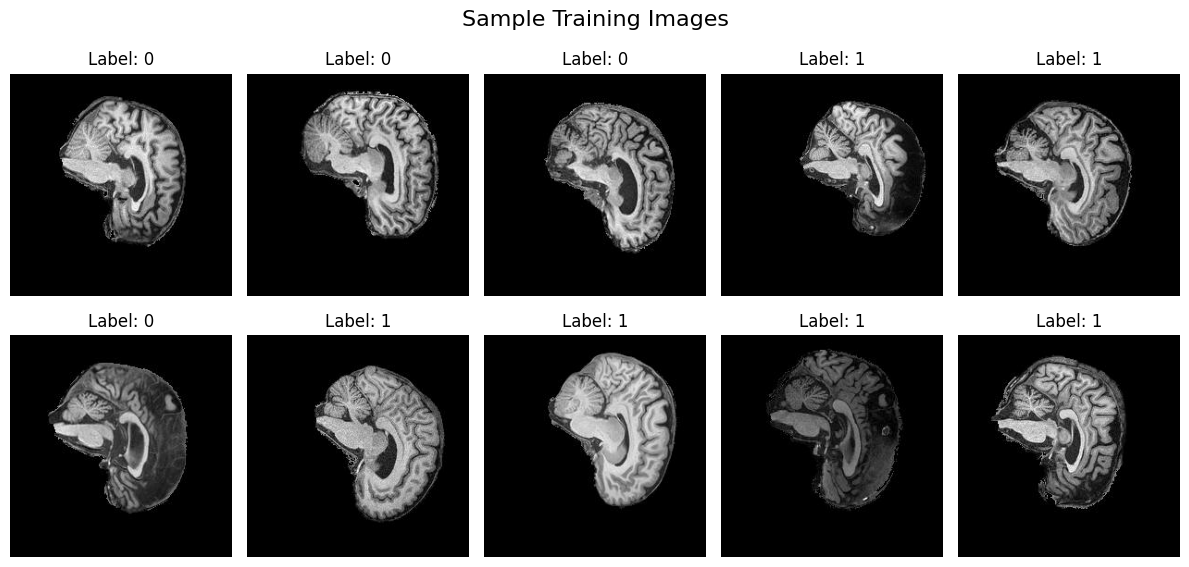

In [ ]:
import random

# Load and Preprocess MNIST Dataset
# Define transforms

training_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),                               # maintain aspect ratio if needed
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),        # zoom in/out slightly
    transforms.RandomHorizontalFlip(p=0.5),                     # brain is roughly symmetric
    transforms.RandomRotation(10),                              # ±10° tilt; preserves structure
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),   # smooth noise variation
    transforms.ColorJitter(brightness=0.1, contrast=0.1),       # slight intensity changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.263], std=[0.271])  # MNIST mean and std
])
testing_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.263], std=[0.271])  # MNIST mean and std
])

# Load MNIST dataset
'''
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)
'''
train_dir = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/AD_NC/train"
test_dir = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/AD_NC/test"

train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=training_transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=testing_transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Visualize some sample images
'''
def show_mnist_samples(dataset, num_samples=10):
    """Display sample MNIST images"""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Sample MNIST Images', fontsize=16)

    for i in range(num_samples):
        image, label = dataset[i]
        row = i // 5
        col = i % 5

        # Denormalize for display
        image = image.squeeze() * 0.3081 + 0.1307

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'Label: {label}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()
'''
def show_mnist_samples(dataset, num_samples=10):
    """Display sample images"""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Sample Training Images', fontsize=16)

    for i in range(num_samples):
        image, label = dataset[random.randint(0, len(dataset))]
        row = i // 5
        col = i % 5

        # Denormalize for display
        image = image * 0.271 + 0.263
        image = image.squeeze(0)  # remove channel dim

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'Label: {label}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_mnist_samples(train_dataset)

In [4]:
import random
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
import torchvision
import matplotlib.pyplot as plt
from torchvision.transforms import v2

# Define transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.263], std=[0.271])  # Example normalization values
])


training_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),                               # maintain aspect ratio if needed
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),        # zoom in/out slightly
    transforms.RandomHorizontalFlip(p=0.5),                     # brain is roughly symmetric
    transforms.RandomRotation(10),                              # ±10° tilt; preserves structure
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),   # smooth noise variation
    transforms.ColorJitter(brightness=0.1, contrast=0.1),       # slight intensity changes
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # small shifts
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.01, 0.05)),        # occlude small regions
    transforms.Normalize(mean=[0.263], std=[0.271])  # MNIST mean and std
])
testing_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.263], std=[0.271])  # MNIST mean and std
])
'''
training_transform = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.Pad((8, 0, 8, 0)),                               # maintain aspect ratio if needed
    v2.RandomResizedCrop(256, scale=(0.8, 1.0)),        # zoom in/out slightly
    v2.RandomHorizontalFlip(p=0.5),                     # brain is roughly symmetric
    v2.RandomRotation(10),                              # ±10° tilt; preserves structure
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),   # smooth noise variation
    v2.ColorJitter(brightness=0.1, contrast=0.1),       # slight intensity changes
    v2.RandomAffine(degrees=0, translate=(0.05, 0.05)), # small shifts
    v2.ToTensor(),
    v2.RandomErasing(p=0.2, scale=(0.01, 0.05)),        # occlude small regions
    v2.Normalize(mean=[0.263], std=[0.271])  # MNIST mean and std
])
testing_transform = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.Pad((8, 0, 8, 0)),
    v2.ToTensor(),
    v2.Normalize(mean=[0.263], std=[0.271])  # MNIST mean and std
])

mixup = v2.MixUp(alpha=0.2, num_classes=2)
cutmix = v2.CutMix(alpha=1.0, num_classes=2)
mix_cutmix = v2.RandomChoice([mixup, cutmix])
'''


# Load ADNI dataset
train_dir = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/AD_NC/train"
test_dir = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/AD_NC/test"

train_dataset_full = torchvision.datasets.ImageFolder(root=train_dir, transform=training_transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=testing_transform)


# --- Split train_dataset_full into 80% train, 20% validation, by class ---
indices = list(range(len(train_dataset_full)))
labels = [label for _, label in train_dataset_full.samples]

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,      # ensures class balance
    random_state=42
)

train_dataset = Subset(torchvision.datasets.ImageFolder(root=train_dir, transform=training_transform), train_idx)
val_dataset = Subset(torchvision.datasets.ImageFolder(root=train_dir, transform=testing_transform), val_idx)


# --- Create DataLoaders ---
batch_size = 128
num_workers = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

# --- Print dataset sizes ---
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training samples: 17216
Validation samples: 4304
Test samples: 9000
Batch size: 128
Training batches: 135
Validation batches: 34
Test batches: 71


In [ ]:
import os, re, random
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
import torchvision

# --- Define transforms ---
training_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.01, 0.05)),
    transforms.Normalize(mean=[0.263], std=[0.271]),
])

testing_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Pad((8, 0, 8, 0)),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.263], std=[0.271]),
])

# --- Load dataset (without transform first) ---
train_dir = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/AD_NC/train"
test_dir = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/AD_NC/test"

dataset_full = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=testing_transform)

# --- Extract patient IDs from filenames (first 6 digits) ---
def extract_patient_id(path):
    filename = os.path.basename(path)
    match = re.match(r"(\d{6})", filename)
    return match.group(1) if match else None

patient_ids = [extract_patient_id(path) for path, _ in dataset_full.samples]
labels = [label for _, label in dataset_full.samples]

# --- Map each sample to its patient ID ---
patient_to_indices = {}
for idx, pid in enumerate(patient_ids):
    if pid is None:
        continue
    patient_to_indices.setdefault(pid, []).append(idx)

unique_patients = list(patient_to_indices.keys())

# --- Split patients instead of images ---
train_pids, val_pids = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42,
    stratify=[labels[patient_to_indices[pid][0]] for pid in unique_patients]
)

# --- Collect image indices by patient group ---
train_indices = [i for pid in train_pids for i in patient_to_indices[pid]]
val_indices = [i for pid in val_pids for i in patient_to_indices[pid]]

print(f"Unique patients total: {len(unique_patients)}")
print(f"Train patients: {len(train_pids)}, Val patients: {len(val_pids)}")

# --- Build datasets with transforms ---
train_dataset = Subset(
    torchvision.datasets.ImageFolder(root=train_dir, transform=training_transform),
    train_indices
)

val_dataset = Subset(
    torchvision.datasets.ImageFolder(root=train_dir, transform=testing_transform),
    val_indices
)

# --- Create dataloaders ---
batch_size = 128
num_workers = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

# --- Summary ---
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


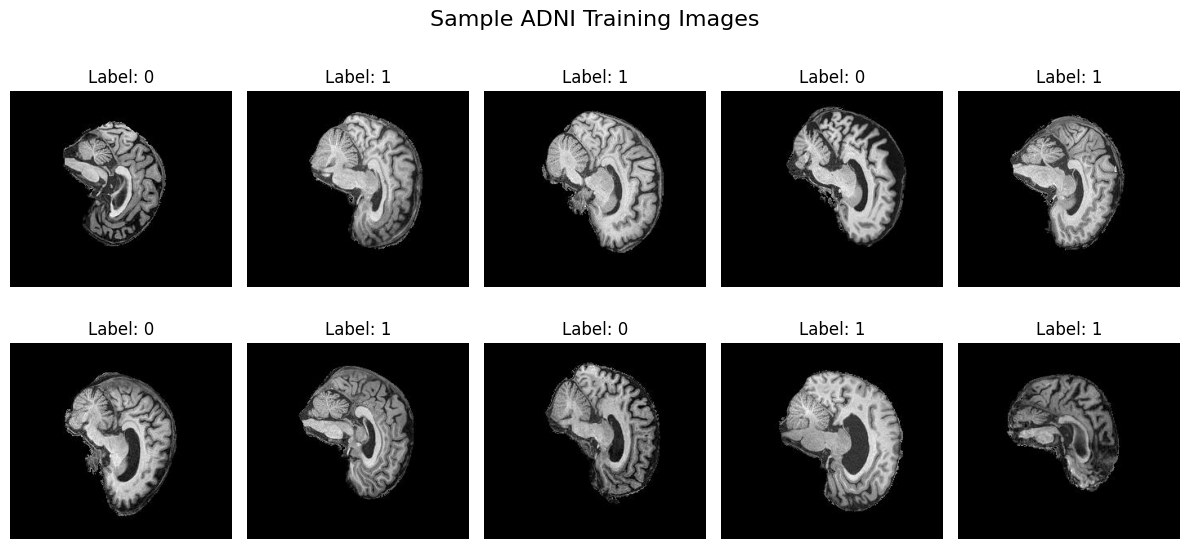

In [5]:
# --- Visualize some samples ---
def show_samples(dataset, num_samples=10, title="Sample Images"):
    """Display sample images from a dataset"""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle(title, fontsize=16)

    for i in range(num_samples):
        image, label = dataset[random.randint(0, len(dataset)-1)]
        row, col = divmod(i, 5)
        image = image * 0.271 + 0.263  # denormalize
        image = image.squeeze(0)
        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'Label: {label}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# Display some random training images
show_samples(val_dataset, title="Sample ADNI Training Images")

In [6]:
from collections import Counter
import numpy as np

def count_classes(dataset, name="Dataset"):
    """
    Count the number of samples per class in a dataset (works for ImageFolder or Subset).
    """
    if isinstance(dataset, torch.utils.data.Subset):
        # Access underlying dataset and the indices
        targets = np.array([dataset.dataset.samples[i][1] for i in dataset.indices])
    else:
        # Direct ImageFolder dataset
        targets = np.array([s[1] for s in dataset.samples])

    class_weights = []

    counts = Counter(targets)
    print(f"\n{name} class distribution:")
    for cls_idx, count in counts.items():
        class_name = dataset.dataset.classes[cls_idx] if isinstance(dataset, torch.utils.data.Subset) else dataset.classes[cls_idx]
        print(f"  {class_name}: {count}")

        class_weights.append(len(targets)/(len(counts.items())*count))

    print(f"  Total: {len(targets)}")

    return class_weights

# --- Display counts ---
training_class_weights = count_classes(train_dataset, "Training Set")
validation_class_weights = count_classes(val_dataset, "Validation Set")
testing_class_weights = count_classes(test_dataset, "Test Set")

print(training_class_weights)
print(validation_class_weights)
print(testing_class_weights)


Training Set class distribution:
  AD: 8320
  NC: 8896
  Total: 17216

Validation Set class distribution:
  AD: 2080
  NC: 2224
  Total: 4304

Test Set class distribution:
  AD: 4460
  NC: 4540
  Total: 9000
[1.0346153846153847, 0.9676258992805755]
[1.0346153846153847, 0.9676258992805755]
[1.0089686098654709, 0.9911894273127754]


In [ ]:
# Create Vision Transformer Model
class PatchEmbedding(nn.Module):
    """Convert image to patches and embed them"""
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Linear projection of flattened patches
        self.projection = nn.Linear(patch_size * patch_size * in_channels, embed_dim)

    def forward(self, x):
        # x: (batch_size, channels, height, width)
        batch_size = x.shape[0]

        # Reshape to patches
        # (batch_size, channels, height, width) -> (batch_size, num_patches, patch_size^2 * channels)
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size) #Unfolds dimension 2&3 (height&width) into patches (batch_size, channels, number of patch rows, number of path columns, path_size, patch_size)
        x = x.contiguous().view(batch_size, self.num_patches, -1) #(batch_size, num_patches, input_features)

        # Project patches to embedding dimension
        x = self.projection(x) # (batch_size, num_patches, embed_dim)
        return x

class PositionalEncoding(nn.Module):
    """Add positional information to patch embeddings"""
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim)) #learned positional encoding

    def forward(self, x):
        return x + self.pos_embedding

class MultiHeadAttention(nn.Module):
    """Multi-head self-attention mechanism"""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attention_dropout = nn.Dropout(dropout)
        self.output_projection = nn.Linear(embed_dim, embed_dim)
        self.output_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x).reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, batch_size, num_heads, seq_len, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        # Apply attention to values
        attention_output = torch.matmul(attention_weights, v)
        attention_output = attention_output.transpose(1, 2).reshape(batch_size, seq_len, embed_dim)

        # Output projection
        output = self.output_projection(attention_output)
        output = self.output_dropout(output)

        return output, attention_weights

class TransformerEncoderBlock(nn.Module):
    """Single transformer encoder block"""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

        # MLP block
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-attention with residual connection
        attention_output, attention_weights = self.attention(self.layer_norm1(x))
        x = x + attention_output

        # MLP with residual connection
        mlp_output = self.mlp(self.layer_norm2(x))
        x = x + mlp_output

        return x, attention_weights

class VisionTransformer(nn.Module):
    """Vision Transformer for MNIST classification"""
    def __init__(self, img_size=28, patch_size=4, in_channels=1, num_classes=10,
                 embed_dim=64, num_heads=4, num_layers=4, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.patch_embedding = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embedding.num_patches

        # Class token
        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Positional encoding
        self.pos_encoding = PositionalEncoding(num_patches, embed_dim)

        # Transformer encoder blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

        # Layer normalization
        self.layer_norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.classification_head = nn.Linear(embed_dim, num_classes)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size = x.shape[0]

        # Patch embedding
        x = self.patch_embedding(x)  # (batch_size, num_patches, embed_dim)

        # Add class token to interact with all other patch tokens, learning to gather summary information from the entire image for classification prediction
        class_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((class_tokens, x), dim=1)  # (batch_size, num_patches + 1, embed_dim)

        # Add positional encoding
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # Pass through transformer blocks
        attention_weights_list = []
        for transformer_block in self.transformer_blocks:
            x, attention_weights = transformer_block(x)
            attention_weights_list.append(attention_weights)

        # Layer normalization
        x = self.layer_norm(x)

        # Use class token for classification
        class_token_output = x[:, 0]  # First token is class token

        # Classification
        logits = self.classification_head(class_token_output)

        return logits, attention_weights_list

# Create model
model = VisionTransformer(
    img_size=28,
    patch_size=4,
    in_channels=1,
    num_classes=10,
    embed_dim=64,
    num_heads=4,
    num_layers=4,
    mlp_dim=128,
    dropout=0.1
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Vision Transformer created successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Image size: 28x28")
print(f"Patch size: 4x4")
print(f"Number of patches: {(28//4)**2}")
print(f"Embedding dimension: 64")
print(f"Number of transformer layers: 4")
print(f"Number of attention heads: 4")

# Test forward pass
test_input = torch.randn(2, 1, 28, 28).to(device)
with torch.no_grad():
    output, attention_weights = model(test_input)
    print(f"\nTest input shape: {test_input.shape}")
    print(f"Test output shape: {output.shape}")
    print(f"Number of attention weight matrices: {len(attention_weights)}")

Vision Transformer created successfully!
Total parameters: 139,018
Image size: 28x28
Patch size: 4x4
Number of patches: 49
Embedding dimension: 64
Number of transformer layers: 4
Number of attention heads: 4

Test input shape: torch.Size([2, 1, 28, 28])
Test output shape: torch.Size([2, 10])
Number of attention weight matrices: 4


In [ ]:
!pip install --upgrade scikit-image

import math
import logging
from functools import partial
from collections import OrderedDict
from copy import Error, deepcopy
from re import S
from numpy.lib.arraypad import pad
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from timm.data import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
import torch.fft
from torch.nn.modules.container import Sequential

_logger = logging.getLogger(__name__)


def _cfg(url='', **kwargs):
    return {
        'url': url,
        'num_classes': 1000, 'input_size': (3, 224, 224), 'pool_size': None,
        'crop_pct': .9, 'interpolation': 'bicubic',
        'mean': IMAGENET_DEFAULT_MEAN, 'std': IMAGENET_DEFAULT_STD,
        'first_conv': 'patch_embed.proj', 'classifier': 'head',
        **kwargs
    }

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class GlobalFilter(nn.Module):
    def __init__(self, dim, h=14, w=8):
        super().__init__()
        self.complex_weight = nn.Parameter(torch.randn(h, w, dim, 2, dtype=torch.float32) * 0.02)
        self.w = w
        self.h = h

    def forward(self, x, spatial_size=None):
        B, N, C = x.shape
        if spatial_size is None:
            a = b = int(math.sqrt(N))
        else:
            a, b = spatial_size

        x = x.view(B, a, b, C)

        x = x.to(torch.float32)

        x = torch.fft.rfft2(x, dim=(1, 2), norm='ortho')
        weight = torch.view_as_complex(self.complex_weight)
        x = x * weight
        x = torch.fft.irfft2(x, s=(a, b), dim=(1, 2), norm='ortho')

        x = x.reshape(B, N, C)

        return x

class Block(nn.Module):

    def __init__(self, dim, mlp_ratio=4., drop=0., drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, h=14, w=8):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.filter = GlobalFilter(dim, h=h, w=w)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.drop_path(self.mlp(self.norm2(self.filter(self.norm1(x)))))
        return x

class BlockLayerScale(nn.Module):

    def __init__(self, dim, mlp_ratio=4., drop=0., drop_path=0., act_layer=nn.GELU,
                norm_layer=nn.LayerNorm, h=14, w=8, init_values=1e-5):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.filter = GlobalFilter(dim, h=h, w=w)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)
        self.gamma = nn.Parameter(init_values * torch.ones((dim)),requires_grad=True)

    def forward(self, x):
        x = x + self.drop_path(self.gamma * self.mlp(self.norm2(self.filter(self.norm1(x)))))
        return x

class PatchEmbed(nn.Module):
    """ Image to Patch Embedding
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        num_patches = (img_size[1] // patch_size[1]) * (img_size[0] // patch_size[0])
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        # FIXME look at relaxing size constraints
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x


class DownLayer(nn.Module):
    """ Image to Patch Embedding
    """
    def __init__(self, img_size=56, dim_in=64, dim_out=128):
        super().__init__()
        self.img_size = img_size
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.proj = nn.Conv2d(dim_in, dim_out, kernel_size=2, stride=2)
        self.num_patches = img_size * img_size // 4

    def forward(self, x):
        B, N, C = x.size()
        x = x.view(B, self.img_size, self.img_size, C).permute(0, 3, 1, 2)
        x = self.proj(x).permute(0, 2, 3, 1)
        x = x.reshape(B, -1, self.dim_out)
        return x

class GFNet(nn.Module):

    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=1000, embed_dim=768, depth=12,
                 mlp_ratio=4., representation_size=None, uniform_drop=False,
                 drop_rate=0., drop_path_rate=0., norm_layer=None,
                 dropcls=0):
        """
        Args:
            img_size (int, tuple): input image size
            patch_size (int, tuple): patch size
            in_chans (int): number of input channels
            num_classes (int): number of classes for classification head
            embed_dim (int): embedding dimension
            depth (int): depth of transformer
            num_heads (int): number of attention heads
            mlp_ratio (int): ratio of mlp hidden dim to embedding dim
            qkv_bias (bool): enable bias for qkv if True
            qk_scale (float): override default qk scale of head_dim ** -0.5 if set
            representation_size (Optional[int]): enable and set representation layer (pre-logits) to this value if set
            drop_rate (float): dropout rate
            attn_drop_rate (float): attention dropout rate
            drop_path_rate (float): stochastic depth rate
            hybrid_backbone (nn.Module): CNN backbone to use in-place of PatchEmbed module
            norm_layer: (nn.Module): normalization layer
        """
        super().__init__()
        self.num_classes = num_classes
        self.num_features = self.embed_dim = embed_dim  # num_features for consistency with other models
        norm_layer = norm_layer or partial(nn.LayerNorm, eps=1e-6)

        self.patch_embed = PatchEmbed(
                img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        h = img_size // patch_size
        w = h // 2 + 1

        if uniform_drop:
            print('using uniform droppath with expect rate', drop_path_rate)
            dpr = [drop_path_rate for _ in range(depth)]  # stochastic depth decay rule
        else:
            print('using linear droppath with expect rate', drop_path_rate * 0.5)
            dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]  # stochastic depth decay rule
        # dpr = [drop_path_rate for _ in range(depth)]  # stochastic depth decay rule

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, mlp_ratio=mlp_ratio,
                drop=drop_rate, drop_path=dpr[i], norm_layer=norm_layer, h=h, w=w)
            for i in range(depth)])

        self.norm = norm_layer(embed_dim)

        # Representation layer
        if representation_size:
            self.num_features = representation_size
            self.pre_logits = nn.Sequential(OrderedDict([
                ('fc', nn.Linear(embed_dim, representation_size)),
                ('act', nn.Tanh())
            ]))
        else:
            self.pre_logits = nn.Identity()

        # Classifier head
        self.head = nn.Linear(self.num_features, num_classes) if num_classes > 0 else nn.Identity()

        if dropcls > 0:
            print('dropout %.2f before classifier' % dropcls)
            self.final_dropout = nn.Dropout(p=dropcls)
        else:
            self.final_dropout = nn.Identity()

        trunc_normal_(self.pos_embed, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'pos_embed', 'cls_token'}

    def get_classifier(self):
        return self.head

    def reset_classifier(self, num_classes, global_pool=''):
        self.num_classes = num_classes
        self.head = nn.Linear(self.embed_dim, num_classes) if num_classes > 0 else nn.Identity()

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x).mean(1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.final_dropout(x)
        x = self.head(x)
        return x


class GFNetPyramid(nn.Module):

    def __init__(self, img_size=224, patch_size=4, num_classes=1000, embed_dim=[64, 128, 256, 512], depth=[2,2,10,4],
                 mlp_ratio=[4, 4, 4, 4],
                 drop_rate=0., drop_path_rate=0., norm_layer=None, init_values=0.001, no_layerscale=False, dropcls=0):
        """
        Args:
            img_size (int, tuple): input image size
            patch_size (int, tuple): patch size
            in_chans (int): number of input channels
            num_classes (int): number of classes for classification head
            embed_dim (int): embedding dimension
            depth (int): depth of transformer
            num_heads (int): number of attention heads
            mlp_ratio (int): ratio of mlp hidden dim to embedding dim
            qkv_bias (bool): enable bias for qkv if True
            qk_scale (float): override default qk scale of head_dim ** -0.5 if set
            representation_size (Optional[int]): enable and set representation layer (pre-logits) to this value if set
            drop_rate (float): dropout rate
            attn_drop_rate (float): attention dropout rate
            drop_path_rate (float): stochastic depth rate
            hybrid_backbone (nn.Module): CNN backbone to use in-place of PatchEmbed module
            norm_layer: (nn.Module): normalization layer
        """
        super().__init__()
        self.num_classes = num_classes
        self.num_features = self.embed_dim = embed_dim[-1]  # num_features for consistency with other models
        norm_layer = norm_layer or partial(nn.LayerNorm, eps=1e-6)

        self.patch_embed = nn.ModuleList()

        patch_embed = PatchEmbed(
                img_size=img_size, patch_size=patch_size, in_chans=3, embed_dim=embed_dim[0])
        num_patches = patch_embed.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim[0]))

        self.patch_embed.append(patch_embed)

        sizes = [56, 28, 14, 7]
        for i in range(4):
            sizes[i] = sizes[i] * img_size // 224

        for i in range(3):
            patch_embed = DownLayer(sizes[i], embed_dim[i], embed_dim[i+1])
            num_patches = patch_embed.num_patches
            self.patch_embed.append(patch_embed)


        self.pos_drop = nn.Dropout(p=drop_rate)
        self.blocks = nn.ModuleList()

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depth))]  # stochastic depth decay rule
        cur = 0
        for i in range(4):
            h = sizes[i]
            w = h // 2 + 1

            if no_layerscale:
                print('using standard block')
                blk = nn.Sequential(*[
                    Block(
                    dim=embed_dim[i], mlp_ratio=mlp_ratio[i],
                    drop=drop_rate, drop_path=dpr[cur + j], norm_layer=norm_layer, h=h, w=w)
                for j in range(depth[i])
                ])
            else:
                print('using layerscale block')
                blk = nn.Sequential(*[
                    BlockLayerScale(
                    dim=embed_dim[i], mlp_ratio=mlp_ratio[i],
                    drop=drop_rate, drop_path=dpr[cur + j], norm_layer=norm_layer, h=h, w=w, init_values=init_values)
                for j in range(depth[i])
                ])
            self.blocks.append(blk)
            cur += depth[i]

        # Classifier head
        self.norm = norm_layer(embed_dim[-1])

        self.head = nn.Linear(self.num_features, num_classes)

        if dropcls > 0:
            print('dropout %.2f before classifier' % dropcls)
            self.final_dropout = nn.Dropout(p=dropcls)
        else:
            self.final_dropout = nn.Identity()

        trunc_normal_(self.pos_embed, std=.02)
        self.apply(self._init_weights)


    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'pos_embed', 'cls_token'}

    def get_classifier(self):
        return self.head

    def reset_classifier(self, num_classes, global_pool=''):
        self.num_classes = num_classes
        self.head = nn.Linear(self.embed_dim, num_classes) if num_classes > 0 else nn.Identity()

    def forward_features(self, x):
        for i in range(4):
            x = self.patch_embed[i](x)
            if i == 0:
                x = x + self.pos_embed
            x = self.blocks[i](x)

        x = self.norm(x).mean(1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.final_dropout(x)
        x = self.head(x)
        return x

def resize_pos_embed(posemb, posemb_new):
    # Rescale the grid of position embeddings when loading from state_dict. Adapted from
    # https://github.com/google-research/vision_transformer/blob/00883dd691c63a6830751563748663526e811cee/vit_jax/checkpoint.py#L224
    _logger.info('Resized position embedding: %s to %s', posemb.shape, posemb_new.shape)
    ntok_new = posemb_new.shape[1]
    if True:
        posemb_tok, posemb_grid = posemb[:, :1], posemb[0, 1:]
        ntok_new -= 1
    else:
        posemb_tok, posemb_grid = posemb[:, :0], posemb[0]
    gs_old = int(math.sqrt(len(posemb_grid)))
    gs_new = int(math.sqrt(ntok_new))
    _logger.info('Position embedding grid-size from %s to %s', gs_old, gs_new)
    posemb_grid = posemb_grid.reshape(1, gs_old, gs_old, -1).permute(0, 3, 1, 2)
    posemb_grid = F.interpolate(posemb_grid, size=(gs_new, gs_new), mode='bilinear')
    posemb_grid = posemb_grid.permute(0, 2, 3, 1).reshape(1, gs_new * gs_new, -1)
    posemb = torch.cat([posemb_tok, posemb_grid], dim=1)
    return posemb


def checkpoint_filter_fn(state_dict, model):
    """ convert patch embedding weight from manual patchify + linear proj to conv"""
    out_dict = {}
    if 'model' in state_dict:
        # For deit models
        state_dict = state_dict['model']
    for k, v in state_dict.items():
        if 'patch_embed.proj.weight' in k and len(v.shape) < 4:
            # For old models that I trained prior to conv based patchification
            O, I, H, W = model.patch_embed.proj.weight.shape
            v = v.reshape(O, -1, H, W)
        elif k == 'pos_embed' and v.shape != model.pos_embed.shape:
            # To resize pos embedding when using model at different size from pretrained weights
            v = resize_pos_embed(v, model.pos_embed)
        out_dict[k] = v
    return out_dict

ModuleNotFoundError: No module named 'numpy.lib.arraypad'

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.layers import trunc_normal_, DropPath
from timm.models.registry import register_model

class Block(nn.Module):
    r""" ConvNeXt Block. There are two equivalent implementations:
    (1) DwConv -> LayerNorm (channels_first) -> 1x1 Conv -> GELU -> 1x1 Conv; all in (N, C, H, W)
    (2) DwConv -> Permute to (N, H, W, C); LayerNorm (channels_last) -> Linear -> GELU -> Linear; Permute back
    We use (2) as we find it slightly faster in PyTorch

    Args:
        dim (int): Number of input channels.
        drop_path (float): Stochastic depth rate. Default: 0.0
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
    """
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim) # depthwise conv
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim) # pointwise/1x1 convs, implemented with linear layers
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)),
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1) # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2) # (N, H, W, C) -> (N, C, H, W)

        x = input + self.drop_path(x)
        return x

class ConvNeXt(nn.Module):
    r""" ConvNeXt
        A PyTorch impl of : `A ConvNet for the 2020s`  -
          https://arxiv.org/pdf/2201.03545.pdf

    Args:
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        depths (tuple(int)): Number of blocks at each stage. Default: [3, 3, 9, 3]
        dims (int): Feature dimension at each stage. Default: [96, 192, 384, 768]
        drop_path_rate (float): Stochastic depth rate. Default: 0.
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
        head_init_scale (float): Init scaling value for classifier weights and biases. Default: 1.
    """
    def __init__(self, in_chans=3, num_classes=1000,
                 depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], drop_path_rate=0.,
                 layer_scale_init_value=1e-6, head_init_scale=1.,
                 ):
        super().__init__()

        self.downsample_layers = nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first")
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                    LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                    nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(downsample_layer)

        self.stages = nn.ModuleList() # 4 feature resolution stages, each consisting of multiple residual blocks
        dp_rates=[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[Block(dim=dims[i], drop_path=dp_rates[cur + j],
                layer_scale_init_value=layer_scale_init_value) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.norm = nn.LayerNorm(dims[-1], eps=1e-6) # final norm layer
        self.head = nn.Linear(dims[-1], num_classes)
        '''
        self.head = nn.Sequential( #NEW ADDITION
            nn.Dropout(0.3),
            nn.Linear(dims[-1], num_classes)
        )
        '''

        self.apply(self._init_weights)
        self.head.weight.data.mul_(head_init_scale)
        self.head.bias.data.mul_(head_init_scale)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            trunc_normal_(m.weight, std=.02)
            nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        return self.norm(x.mean([-2, -1])) # global average pooling, (N, C, H, W) -> (N, C)

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

class LayerNorm(nn.Module):
    r""" LayerNorm that supports two data formats: channels_last (default) or channels_first.
    The ordering of the dimensions in the inputs. channels_last corresponds to inputs with
    shape (batch_size, height, width, channels) while channels_first corresponds to inputs
    with shape (batch_size, channels, height, width).
    """
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

In [8]:
model = ConvNeXt(
        in_chans=1,
        num_classes=2,
        depths=[3, 3, 9, 3],
        dims=[96, 192, 384, 768],
        drop_path_rate=0.1,  # small regularization
        layer_scale_init_value=1e-6,
        head_init_scale=1.0
    )

In [110]:
model = ConvNeXt(
        in_chans=1,
        num_classes=2,
        depths=[2, 2, 4, 2],
        dims=[48, 96, 192, 384],
        drop_path_rate=0.1,  # small regularization
        layer_scale_init_value=1e-6,
        head_init_scale=1.0
    )

Sample image label: 5


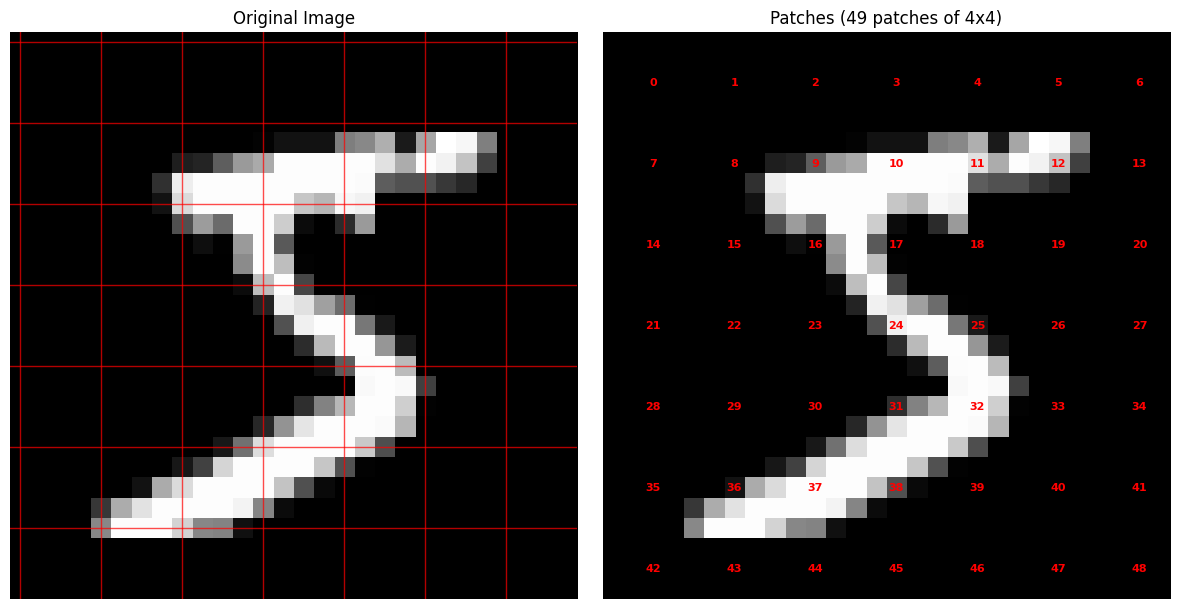

Number of patches extracted: 49
Each patch size: torch.Size([4, 4])

Patch Embedding Test:
Input shape: torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 49, 64])
Number of patches: 49
Embedding dimension: 64


In [ ]:
# Prepare Data for Transformer and Visualize Patches
def visualize_patches(image, patch_size=4):
    """Visualize how an image is divided into patches"""
    # Denormalize image for visualization
    image = image.squeeze() * 0.3081 + 0.1307

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Draw patch boundaries
    height, width = image.shape
    for i in range(0, height, patch_size):
        axes[0].axhline(i, color='red', linewidth=1, alpha=0.7)
    for j in range(0, width, patch_size):
        axes[0].axvline(j, color='red', linewidth=1, alpha=0.7)

    # Extract and display patches
    num_patches_per_side = height // patch_size
    patches = []

    for i in range(num_patches_per_side):
        for j in range(num_patches_per_side):
            patch = image[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            patches.append(patch)

    # Display patches
    patch_grid = np.zeros((num_patches_per_side * patch_size, num_patches_per_side * patch_size))
    for idx, patch in enumerate(patches):
        i = idx // num_patches_per_side
        j = idx % num_patches_per_side
        patch_grid[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = patch

    axes[1].imshow(patch_grid, cmap='gray')
    axes[1].set_title(f'Patches ({len(patches)} patches of {patch_size}x{patch_size})')
    axes[1].axis('off')

    # Add patch numbers
    for idx in range(len(patches)):
        i = idx // num_patches_per_side
        j = idx % num_patches_per_side
        y = i * patch_size + patch_size // 2
        x = j * patch_size + patch_size // 2
        axes[1].text(x, y, str(idx), ha='center', va='center',
                    color='red', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return patches

# Visualize patch extraction
sample_image, sample_label = train_dataset[0]
print(f"Sample image label: {sample_label}")
patches = visualize_patches(sample_image, patch_size=4)
print(f"Number of patches extracted: {len(patches)}")
print(f"Each patch size: {patches[0].shape}")

# Test patch embedding
def test_patch_embedding():
    """Test the patch embedding process"""
    patch_embed = PatchEmbedding(img_size=28, patch_size=4, in_channels=1, embed_dim=64)

    # Test with a batch of images
    test_batch = torch.randn(4, 1, 28, 28)
    embedded_patches = patch_embed(test_batch)

    print(f"\nPatch Embedding Test:")
    print(f"Input shape: {test_batch.shape}")
    print(f"Output shape: {embedded_patches.shape}")
    print(f"Number of patches: {patch_embed.num_patches}")
    print(f"Embedding dimension: 64")

    return embedded_patches

embedded_patches = test_patch_embedding()

In [ ]:
from torch.optim.lr_scheduler import LambdaLR

def get_cosine_schedule_with_warmup(optimizer, num_warmup_epochs, num_training_epochs, num_cycles=0.5):
    """
    Returns a scheduler that warms up linearly for num_warmup_epochs,
    then decays via cosine over remaining epochs.
    """
    def lr_lambda(current_epoch):
        if current_epoch < num_warmup_epochs:
            # Linear warmup: increase LR proportionally to epoch progress
            return float(current_epoch) / float(max(1, num_warmup_epochs))
        # Cosine decay: smoothly reduce LR after warmup
        progress = float(current_epoch - num_warmup_epochs) / float(max(1, num_training_epochs - num_warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * num_cycles * 2 * progress))

    return LambdaLR(optimizer, lr_lambda)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
from sklearn.metrics import classification_report
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.memory_summary(device=None, abbreviated=True))

# Initialize model
model = model.to(device)

# Training configuration
num_epochs = 120
num_warmup_epochs = 10
learning_rate = 2.5e-4
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=torch.tensor(training_class_weights, dtype=torch.float32, device=device))#criterion = nn.BCEWithLogitsLoss() #
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
#scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_epochs, num_epochs)
scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=num_warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - num_warmup_epochs), eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[num_warmup_epochs])


# Lists to store training history
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# ---------------------------
# Training and Validation Loops
# ---------------------------

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    progress_bar = tqdm(loader, desc="Training", leave=True)
    for data, targets in progress_bar:
        data, targets = data.to(device), targets.to(device)

        #data, targets = mix_cutmix(data, targets) #For MixUp and CutMix

        optimizer.zero_grad()
        outputs = model(data)

        #For Cutmix and Mixup
        #loss = torch.mean(torch.sum(-targets * F.log_softmax(outputs, dim=1), dim=1))
        #targets = F.one_hot(targets, num_classes=2).float()  # (B, 2)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        progress_bar.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{100*correct/total:.2f}%")

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc=desc, leave=True)
        for data, targets in progress_bar:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            progress_bar.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{100*correct/total:.2f}%")

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


# ---------------------------
# Training Loop
# ---------------------------
print("🚀 Starting ConvNeXt-Tiny Training on ADNI!")
print("=" * 60)

best_val_acc = 0.0
patience = 100
epochs_no_improve = 0
early_stop = False

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Validation")

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_convnext_adni.pth")
        print(f"✅ New best validation accuracy: {best_val_acc:.2f}%")
        epochs_no_improve = 0  # reset counter
    else:
      epochs_no_improve += 1
      print(f"⚠️ No improvement for {epochs_no_improve} epoch(s).")

      if epochs_no_improve >= patience:
          print(f"⏹️ Early stopping triggered after {epoch+1} epochs!")
          early_stop = True
          break

print("\n🎉 Training complete!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

cuda
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|----------------------------------------------------------

Training:  36%|███▌      | 48/135 [08:40<03:46,  2.60s/it, Acc=50.60%, Loss=0.6850]

In [136]:
# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n📊 Evaluating Best Model on Test Set...")
model.load_state_dict(torch.load("best_convnext_adni.pth", map_location=device))

def detailed_evaluation(model, loader, device, class_names):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds, all_targets = np.array(all_preds), np.array(all_targets)
    accuracy = (all_preds == all_targets).mean() * 100
    print(f"\n✅ Test Accuracy: {accuracy:.4f}%")
    print("\n📋 Classification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))
    return all_preds, all_targets, all_probs

# Class names from dataset
class_names = train_dataset.dataset.classes if isinstance(train_dataset, torch.utils.data.Subset) else train_dataset.classes
preds, targets, probs = detailed_evaluation(model, test_loader, device, class_names)


📊 Evaluating Best Model on Test Set...

✅ Test Accuracy: 68.8333%

📋 Classification Report:
              precision    recall  f1-score   support

          AD       0.68      0.69      0.69      4460
          NC       0.69      0.69      0.69      4540

    accuracy                           0.69      9000
   macro avg       0.69      0.69      0.69      9000
weighted avg       0.69      0.69      0.69      9000



In [ ]:
# Train the Model
# Training configuration
num_epochs = 20
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Lists to store training history
train_losses = []
train_accuracies = []
test_accuracies = []

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc='Training')
    for batch_idx, (data, targets) in enumerate(progress_bar):
        data, targets = data.to(device), targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs, _ = model(data)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def test_epoch(model, test_loader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs, _ = model(data)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

# Training loop
print("🚀 Starting Vision Transformer Training!")
print("=" * 60)

best_test_acc = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Test
    test_loss, test_acc = test_epoch(model, test_loader, criterion, device)

    # Store history
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_vit_mnist.pth')
        print(f"✅ New best test accuracy: {best_test_acc:.2f}%")

print(f"\n🎉 Training completed!")
print(f"Best test accuracy: {best_test_acc:.2f}%")

🚀 Starting Vision Transformer Training!

Epoch 1/20
------------------------------


Training: 100%|██████████| 938/938 [00:19<00:00, 49.16it/s, Loss=0.1999, Acc=82.76%]


Train Loss: 0.5306 | Train Acc: 82.76%
Test Loss: 0.1835 | Test Acc: 94.25%
✅ New best test accuracy: 94.25%

Epoch 2/20
------------------------------


Training: 100%|██████████| 938/938 [00:20<00:00, 45.14it/s, Loss=0.3661, Acc=93.25%]


Train Loss: 0.2157 | Train Acc: 93.25%
Test Loss: 0.1161 | Test Acc: 96.34%
✅ New best test accuracy: 96.34%

Epoch 3/20
------------------------------


...

Train Loss: 0.0554 | Train Acc: 98.17%
Test Loss: 0.0528 | Test Acc: 98.38%

Epoch 19/20
------------------------------


Training: 100%|██████████| 938/938 [00:16<00:00, 56.85it/s, Loss=0.0789, Acc=98.25%]


Train Loss: 0.0520 | Train Acc: 98.25%
Test Loss: 0.0508 | Test Acc: 98.38%

Epoch 20/20
------------------------------


Training: 100%|██████████| 938/938 [00:17<00:00, 54.09it/s, Loss=0.0053, Acc=98.35%]


Train Loss: 0.0509 | Train Acc: 98.35%
Test Loss: 0.0492 | Test Acc: 98.55%
✅ New best test accuracy: 98.55%

🎉 Training completed!
Best test accuracy: 98.55%


In [ ]:
# Evaluate Model Performance
# Load best model
model.load_state_dict(torch.load('best_vit_mnist.pth'))

# Detailed evaluation
def detailed_evaluation(model, test_loader, device):
    """Perform detailed evaluation with per-class metrics"""
    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs, _ = model(data)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)

print("📊 Detailed Model Evaluation")
print("=" * 40)

predictions, targets, probabilities = detailed_evaluation(model, test_loader, device)

# Overall accuracy
accuracy = (predictions == targets).mean() * 100
print(f"Overall Test Accuracy: {accuracy:.2f}%")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(targets, predictions, target_names=[str(i) for i in range(10)]))

print(f"\n✅ Evaluation completed!")

📊 Detailed Model Evaluation
Overall Test Accuracy: 98.55%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


✅ Evaluation completed!


NameError: name 'test_accuracies' is not defined

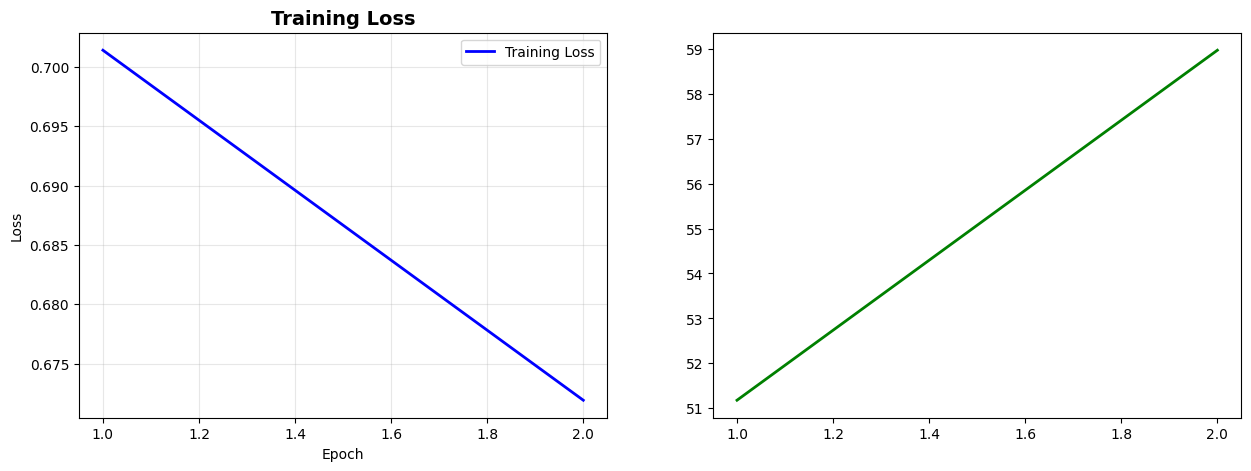

In [133]:
# Visualize Results and Predictions
# Plot training curves
def plot_training_curves():
    """Plot training loss and accuracy curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, len(train_losses) + 1)

    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs, train_accuracies, 'g-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Test Accuracy', linewidth=2)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves()

# Visualize attention maps
def visualize_attention(model, image, label, patch_size=4):
    """Visualize attention weights for a given image"""
    model.eval()

    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        outputs, attention_weights_list = model(image_batch)

        # Get prediction
        probabilities = F.softmax(outputs, dim=1)
        predicted_class = outputs.argmax(dim=1).item()
        confidence = probabilities.max().item()

    # Denormalize image for display
    img_display = image.squeeze() * 0.3081 + 0.1307

    # Use attention from the last layer
    attention = attention_weights_list[-1][0]  # First sample, last layer

    # Average attention across heads and get attention to patches (excluding class token)
    patch_attention = attention.mean(dim=0)[0, 1:].cpu()  # Class token attention to patches

    # Reshape attention to spatial dimensions
    num_patches_per_side = int(math.sqrt(len(patch_attention)))
    attention_map = patch_attention.reshape(num_patches_per_side, num_patches_per_side)

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img_display, cmap='gray')
    axes[0].set_title(f'Original Image\nTrue: {label}, Pred: {predicted_class}')
    axes[0].axis('off')

    # Attention map
    im1 = axes[1].imshow(attention_map, cmap='hot', interpolation='nearest')
    axes[1].set_title('Attention Map')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Overlay attention on image
    # Resize attention map to match image size
    attention_resized = F.interpolate(
        attention_map.unsqueeze(0).unsqueeze(0),
        size=(28, 28),
        mode='bilinear',
        align_corners=False
    ).squeeze()

    axes[2].imshow(img_display, cmap='gray', alpha=0.7)
    axes[2].imshow(attention_resized, cmap='hot', alpha=0.5)
    axes[2].set_title(f'Attention Overlay\nConfidence: {confidence:.3f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize predictions with attention
def show_sample_predictions(model, test_dataset, num_samples=6):
    """Show sample predictions with attention maps"""
    print("🔍 Sample Predictions with Attention Maps")
    print("=" * 50)

    # Get some test samples
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        print(f"\nSample {i+1}:")
        image, label = test_dataset[idx]
        visualize_attention(model, image, label)

show_sample_predictions(model, test_dataset, num_samples=4)

# Compare with wrong predictions
def show_wrong_predictions(model, test_loader, device, num_samples=4):
    """Show examples where the model made wrong predictions"""
    model.eval()
    wrong_examples = []

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs, attention_weights = model(data)
            _, predicted = outputs.max(1)

            # Find wrong predictions
            wrong_mask = predicted != targets
            if wrong_mask.any():
                wrong_indices = torch.where(wrong_mask)[0]
                for idx in wrong_indices:
                    if len(wrong_examples) < num_samples:
                        wrong_examples.append({
                            'image': data[idx].cpu(),
                            'true_label': targets[idx].item(),
                            'predicted_label': predicted[idx].item(),
                            'confidence': F.softmax(outputs[idx], dim=0).max().item()
                        })

    print("\n❌ Wrong Predictions Analysis")
    print("=" * 40)

    for i, example in enumerate(wrong_examples):
        print(f"\nWrong Prediction {i+1}:")
        visualize_attention(model, example['image'], example['true_label'])
        print(f"True: {example['true_label']}, Predicted: {example['predicted_label']}, "
              f"Confidence: {example['confidence']:.3f}")

if len([p for p in predictions if p != targets[np.where(predictions == p)[0][0]]]) > 0:
    show_wrong_predictions(model, test_loader, device, num_samples=2)

print("\n🎉 Visualization complete!")

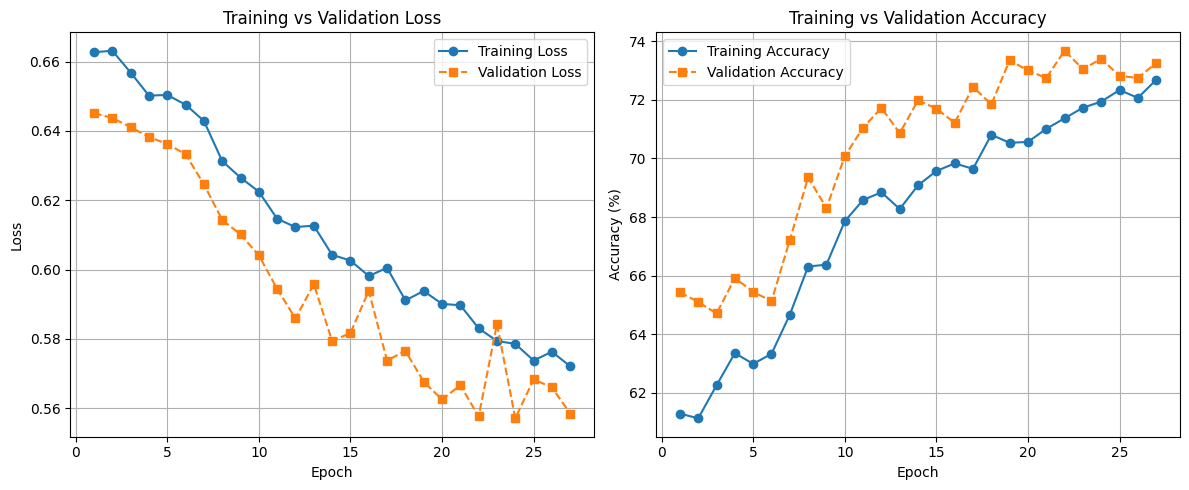

<Figure size 600x600 with 0 Axes>

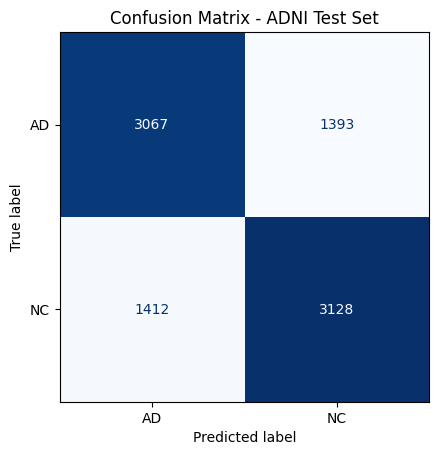

<Figure size 600x600 with 0 Axes>

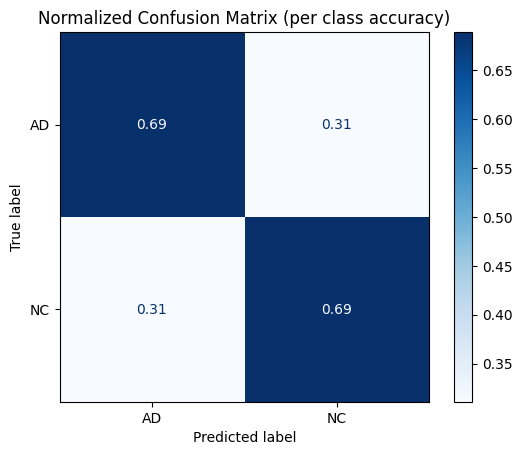

In [137]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# 1. Plot Loss and Accuracy
# ---------------------------

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# --- Loss plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Training Loss')
plt.plot(epochs, val_losses, 's--', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Accuracy plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'o-', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 's--', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------
# 2. Confusion Matrix
# ---------------------------
cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', colorbar=False)
plt.title("Confusion Matrix - ADNI Test Set")
plt.show()

# Optional: Normalized confusion matrix
cm_normalized = confusion_matrix(targets, preds, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)

plt.figure(figsize=(6, 6))
disp_norm.plot(cmap='Blues', values_format='.2f', colorbar=True)
plt.title("Normalized Confusion Matrix (per class accuracy)")
plt.show()


In [ ]:
from sklearn.metrics import f1_score

def find_best_threshold(probs, targets):
    thresholds = np.linspace(0.1, 0.9, 9)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        preds = (probs > t).astype(int)
        f1 = f1_score(targets, preds)
        print(f"Threshold {t:.2f} → F1: {f1:.3f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"\n✅ Best threshold: {best_t:.2f} (F1 = {best_f1:.3f})")
    return best_t

find_best_threshold(probabilities, targets)